In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
df = pd.read_csv("/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/train.csv")

In [5]:
df.shape

(6818, 13)

In [6]:
# check the info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


In [7]:
# check the few rows
df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [8]:
df.describe(include="all")

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,6818,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,row_00000,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,1,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


In [11]:
# check null values
df.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [32]:
# check the percentage that are missing
print(df.isnull().sum() / len(df) * 100)  

id                      0.000000
product_code            0.000000
product_weight_kg      17.967146
fat_content             0.000000
shelf_visibility        0.000000
product_category        0.000000
product_price           0.000000
store_code              0.000000
store_age_years         0.000000
store_size             28.146084
store_location_tier     0.000000
store_format            0.000000
total_sales             0.000000
dtype: float64


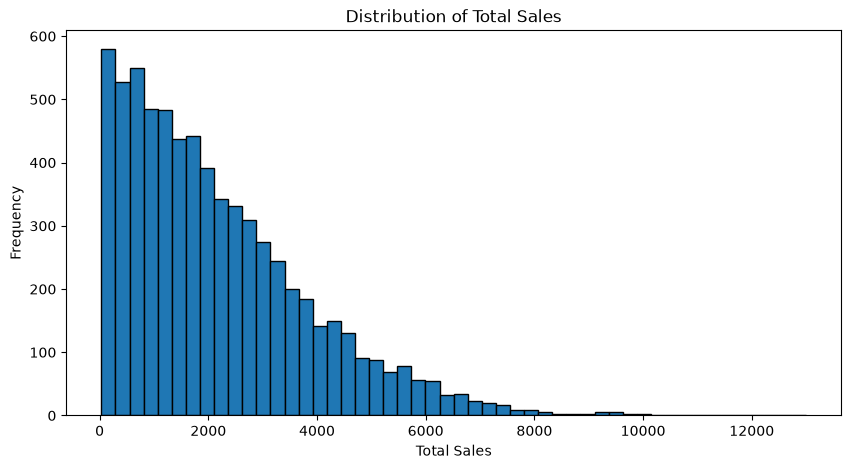

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64


In [36]:
# understand my target variable total_sales
# Visualize sales distribution
plt.figure(figsize=(10, 5))
plt.hist(df['total_sales'], bins=50, edgecolor='black')  # Adjust column name
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Total Sales')
plt.show()

# Basic stats
print(df['total_sales'].describe())


In [38]:
df.columns

Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='str')

In [40]:
print("Fat Content:", df['fat_content'].unique())
print("Product Category:", df['product_category'].unique())
print("Store Size:", df['store_size'].unique())
print("Store Location Tier:", df['store_location_tier'].unique())
print("Store Format:", df['store_format'].unique())

Fat Content: <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
Product Category: <StringArray>
[         'Frozen Foods',    'HEALTH AND HYGIENE',                'Canned',
           'soft drinks',                  'meat',           'Snack Foods',
          'baking goods',             'household',             'Household',
                 'Dairy',                 'dairy',                'CANNED',
           'SNACK FOODS',             'HOUSEHOLD',           'Soft Drinks',
 'Fruits and Vegetables',             'Breakfast',                'Breads',
                  'Meat',          'BAKING GOODS',                'canned',
                 'DAIRY',             'breakfast',          'Baking Goods',
    'Health and Hygiene',                  'MEAT',               'Seafood',
 'fruits and vegetables',          'frozen foods',           'snack foods',
          'FROZEN FOODS',                'Others', 'FRUITS AND VEGETABLES',
    'health and hygiene',                'OTHERS',          

In [41]:
print("\nStore Format Distribution:")
print(df['store_format'].value_counts())

print("\nLocation Tier Distribution:")
print(df['store_location_tier'].value_counts())


Store Format Distribution:
store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

Location Tier Distribution:
store_location_tier
Tier_3    2677
Tier_2    2232
Tier_1    1909
Name: count, dtype: int64


In [42]:
print(df[['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']].describe())

       product_weight_kg  shelf_visibility  product_price  store_age_years  \
count        5593.000000       6818.000000    6818.000000      6818.000000   
mean           12.850876          0.065527     140.473623        34.178205   
std             4.646542          0.051566      62.413513         8.384574   
min             4.482000          0.000000      31.110000        23.000000   
25%             8.750000          0.026600      93.280000        28.000000   
50%            12.647000          0.053200     142.065000        33.000000   
75%            16.894000          0.093400     185.987500        45.000000   
max            21.883000          0.320100     273.040000        47.000000   

        total_sales  
count   6818.000000  
mean    2174.756574  
std     1697.894956  
min       32.700000  
25%      834.792500  
50%     1790.890000  
75%     3092.587500  
max    12996.820000  


In [15]:
# check duplicate vlaues
df.duplicated().sum()

np.int64(0)

In [29]:
# check correlation 
corr_matrix = df.select_dtypes("number")
corr_matrix.head()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
0,14.252,0.0271,81.37,45,1764.98
1,7.698,0.0720,42.05,35,342.13
2,14.264,0.0421,41.35,33,378.85
3,NaN,0.0449,174.35,47,5595.72
4,10.338,0.0120,203.06,28,2375.36


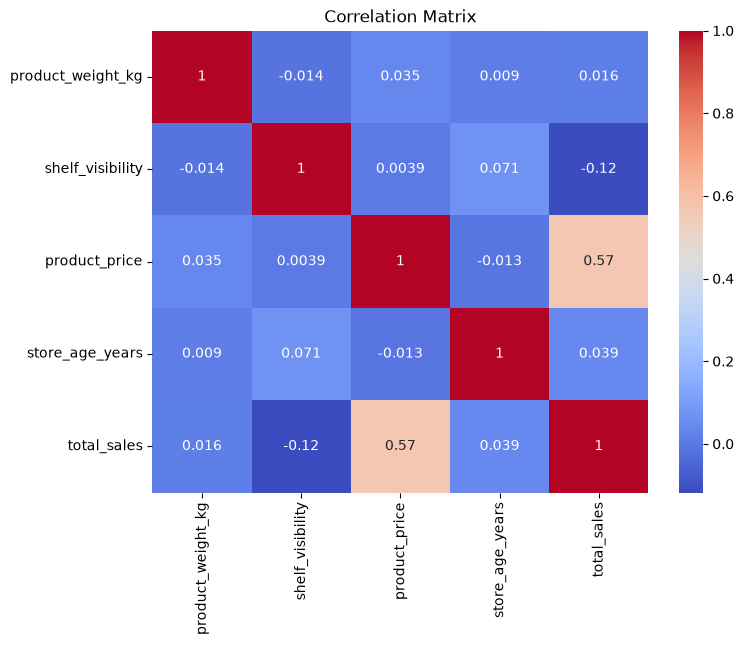


Correlation with Total Sales:
total_sales          1.000000
product_price        0.569833
store_age_years      0.039443
product_weight_kg    0.015532
shelf_visibility    -0.118124
Name: total_sales, dtype: float64


In [44]:
import seaborn as sns

numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelation with Total Sales:")
print(corr['total_sales'].sort_values(ascending=False))